## 1. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Define Project Paths

In [2]:
BASE_PATH = "/content/drive/MyDrive/job-posting-classifier"

DATA_RAW = BASE_PATH + "/data/raw/linkedin_job_postings.csv"
DATA_PROCESSED = BASE_PATH + "/data/processed/cleaned_data.csv"

## 3. Install Required Libraries

In [3]:
!pip install scikit-learn pandas numpy joblib

## 4. Import Libraries

In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

import joblib

## 5. Load Clean Dataset

In [5]:
df = pd.read_csv(DATA_PROCESSED)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (15886, 2)


,text,formatted_work_type
0,licensed insurance agent while many industries...,Full-time
1,sales manager are you a dynamic and creative m...,Full-time
2,model risk auditor join us as a model risk aud...,Contract
3,business manager business managerfirst baptist...,Full-time
4,ny studio assistant you could be one of the ma...,Full-time


## 6. Split Features and Labels

In [6]:
X = df["text"]

y = df["formatted_work_type"]

## 7. Train/Test Split

In [7]:
X = df["text"]
y = df["formatted_work_type"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
train_df = pd.DataFrame({
    "text": X_train,
    "label": y_train
})

from sklearn.utils import resample

df_full = train_df[train_df["label"] == "Full-time"]
df_contract = train_df[train_df["label"] == "Contract"]
df_part = train_df[train_df["label"] == "Part-time"]
df_other = train_df[train_df["label"] == "Other"]
df_intern = train_df[train_df["label"] == "Internship"]

target_size = 4000

df_contract_up = resample(df_contract, replace=True, n_samples=target_size, random_state=42)
df_part_up = resample(df_part, replace=True, n_samples=target_size, random_state=42)
df_other_up = resample(df_other, replace=True, n_samples=target_size, random_state=42)
df_intern_up = resample(df_intern, replace=True, n_samples=target_size, random_state=42)

train_balanced = pd.concat([
    df_full,
    df_contract_up,
    df_part_up,
    df_other_up,
    df_intern_up
]).sample(frac=1, random_state=42)

X_train = train_balanced["text"]
y_train = train_balanced["label"]

## 8. TF-IDF Vectorization

In [9]:
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,3),
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [10]:
TFIDF_PATH = BASE_PATH + "/models/tfidf_vectorizer.pkl"

joblib.dump(tfidf, TFIDF_PATH)

print("TF-IDF saved at:", TFIDF_PATH)

TF-IDF saved at: /content/drive/MyDrive/job-posting-classifier/models/tfidf_vectorizer.pkl


## 9. Train Linear SVM Model

In [11]:
#model = LinearSVC(class_weight="balanced")
# from sklearn.svm import SVC

# model = SVC(
#     kernel="linear",
#     probability=True,
#     class_weight="balanced"
# )

from sklearn.linear_model import SGDClassifier

model = SGDClassifier(
    loss="log_loss",
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

model.fit(X_train_tfidf, y_train)

SGDClassifier(class_weight='balanced', loss='log_loss', random_state=42)

## 10. Make Predictions

In [12]:
y_pred = model.predict(X_test_tfidf)

## 11. Evaluate Model

In [13]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

Accuracy: 0.9801762114537445

Classification Report:

              precision    recall  f1-score   support

    Contract       0.98      0.98      0.98       348
   Full-time       0.99      0.99      0.99      2570
  Internship       0.67      1.00      0.80        22
       Other       0.72      0.72      0.72        36
   Part-time       0.90      0.97      0.93       202

    accuracy                           0.98      3178
   macro avg       0.85      0.93      0.88      3178
weighted avg       0.98      0.98      0.98      3178



## 12. Confusion Matrix

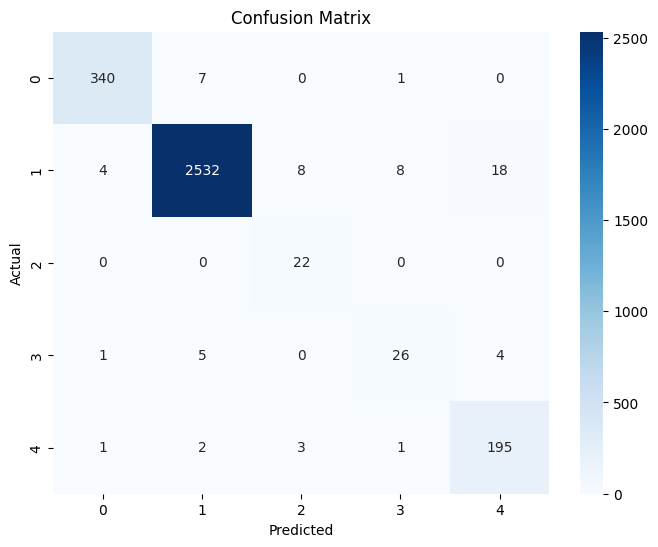

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

## 13. Save Model

In [15]:
BASE_PATH = "/content/drive/MyDrive/job-posting-classifier"

MODEL_PATH = BASE_PATH + "/models/svm_model.pkl"

In [16]:
joblib.dump(model, MODEL_PATH)

print("Model saved at:", MODEL_PATH)

Model saved at: /content/drive/MyDrive/job-posting-classifier/models/svm_model.pkl
